In [1]:
from Bio import SeqIO
import primer3
from choppy.homology_finder import load_trie, create_kmer_trie, merge_tries, find_non_homologous_regions, find_local_non_homologous_regions, get_region_intersects
from choppy.primer_flanked_overlaps import get_primer_overlaps_from_seq, check_primer
import re
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.pyplot as plt
import edlib

In [2]:
all_sequences = list(SeqIO.parse("data/20240414-forSveta.fa", "fasta"))

seq_names = ["Maizel_COS-AT1G27430-GYF2", "Maizel_COS-SETH5", 
             "Pereira_COS-SynDNA-f1", "Pereira_COS-SynDNA-f2",
             "PV252688r_p6utr", "PQ537341r_p6utr,"
             "PQ488556r_p6utr", "PX021458r_p6utr",
             "MZ289137_rep", "OR500095r_naive"]

sequences = [seq for seq in all_sequences if seq.id in seq_names]

for seq in sequences:
    seq.seq = seq.seq.upper()

sequences_by_id = {seq.id: seq for seq in sequences}

In [3]:
min_overlap = 50
max_overlap = 100
min_length = 100 - 40
min_length = max(min_length, min_overlap*2 + 40)
max_length = 1000 - 40
n_frags_max = 5
n_frags_min = 2

CONFIG = {
    'kmer_size': 15,
    'neighbourhood_size': 4500,
    'max_frag_length': 1000,
    'min_frag_length': 200,
    'min_primer_length': 17,
    'max_primer_length': 30,
    'primer_3prime_anchor': 6,
    'min_step': 10,
    'homology_anchor': 6,
    'homology_check': 46,
    'homology_block_size': 10,
    'min_gc': 0.3,
    'max_gc': 0.7,
    'min_tm': 57.0,
    'max_tm': 62.0,
    'max_hairpin_tm': 24.0,
    'max_homodimer_tm': 45.0,
    'max_3_self_tm': 35.0,
    'max_misprime_tm': 47.0,
    'min_overlap': 50,
    'max_overlap': 100,
    'poly_x_pattern': re.compile(r'(A{5,}|T{5,}|G{5,}|C{5,})'),
    'clamp_length': 3,
    'clamp_pattern': re.compile(r'[GC][AT][GC]|[AT][GC][GC]'),
    'five_prime_clamp_pattern': re.compile(r'^[GC]')
}

In [4]:
bg_trie = load_trie("../data/S_cerevisiae-R64-GCA_000146045_cat_15.marisa")
seq_tries = {}
for seq in sequences:
    trie = create_kmer_trie(seq, CONFIG['kmer_size'], bg=False)
    seq_tries[seq.id] = trie 

bg_regions = {}
cur_seq_regions = {}
local_neigh_regions = {}
for seq in sequences:
    bg_regions[seq.id] = find_non_homologous_regions(seq, bg_trie, [], CONFIG['kmer_size'], threshold=CONFIG['min_overlap'])
    cur_seq_regions[seq.id] = find_non_homologous_regions(seq, seq_tries[seq.id], bg_trie, CONFIG['kmer_size'], threshold=CONFIG['min_overlap'])
    local_neigh_regions[seq.id] = find_local_non_homologous_regions(seq, CONFIG['kmer_size'], CONFIG['min_overlap'], CONFIG['neighbourhood_size'])
    local_neigh_regions[seq.id] = get_region_intersects(local_neigh_regions[seq.id], bg_regions[seq.id], CONFIG['min_overlap'])

Processing sequence: 100%|██████████| 5911/5911 [00:00<00:00, 1131252.55it/s]


Found 18 unique k-mers of size 15 in 1 sequence(s).
Constructing a trie...


Processing sequence: 100%|██████████| 8495/8495 [00:00<00:00, 1928376.49it/s]


Found 0 unique k-mers of size 15 in 1 sequence(s).
Constructing a trie...


Processing sequence: 100%|██████████| 21124/21124 [00:00<00:00, 2601000.40it/s]


...

Processing sequence: 100%|██████████| 8034/8034 [00:00<00:00, 3242594.14it/s]


Found 2 unique k-mers of size 15 in 1 sequence(s).
Constructing a trie...


Processing sequence: 100%|██████████| 8137/8137 [00:00<00:00, 3272200.54it/s]


Found 2 unique k-mers of size 15 in 1 sequence(s).
Constructing a trie...


Finding non-homologous regions: 100%|██████████| 8137/8137 [00:00<00:00, 730986.99it/s]


In [5]:
def reverse_complement(seq):
    return seq[::-1].translate(str.maketrans('ATGC', 'TACG'))

def build_anchor_kmers(sequences, anchor_len, reverse_position = True):
    """Builds the 3' k-mer hash map for fast off-target screening."""
    anchor_kmers = defaultdict(list)
    for seq in sequences:
        seq_str = str(seq.seq).upper()
        for pos in range(len(seq_str) - anchor_len + 1):
            kmer_fwd = seq_str[pos:pos + anchor_len]
            kmer_rev = reverse_complement(kmer_fwd)
            
            anchor_kmers[kmer_fwd].append((seq.id, pos + anchor_len - 1, "forward"))
            if reverse_position:
                anchor_kmers[kmer_rev].append((seq.id, len(seq_str) - pos - anchor_len, "reverse"))
            else:
                anchor_kmers[kmer_rev].append((seq.id, pos + anchor_len - 1, "reverse"))
            
    return anchor_kmers

def check_misprime(primer_cand, native_3_prime_pos, side, seq_id, anchor_kmers, sequences_by_id, cfg):
    """Validates the primer against the k-mer map to ensure no high-Tm off-targets."""
    anchor_3 = primer_cand[-cfg['primer_3prime_anchor']:]
    
    for anchor_seq_id, anchor_pos, anchor_side in anchor_kmers.get(anchor_3, []):
        # Allow binding to the intended on-target site
        if anchor_side == side and anchor_seq_id == seq_id and anchor_pos == native_3_prime_pos:
            continue
            
        anchor_seq = str(sequences_by_id[anchor_seq_id].seq).upper()
        
        # Extract the off-target sequence depending on strand orientation
        if anchor_side == "forward":
            pos_misprime = anchor_seq[max(0, anchor_pos - cfg['max_primer_length'] + 1):anchor_pos + 1]
        else:
            pos_misprime = reverse_complement(anchor_seq[anchor_pos:min(len(anchor_seq), anchor_pos + cfg['max_primer_length'])])
            
        if primer3.calc_heterodimer_tm(primer_cand, reverse_complement(pos_misprime)) > cfg['max_misprime_tm']:
            return True
            
    return False

def check_local_misprime(primer_cand, seq_str, native_3_prime_pos, side, seq_id, anchor_kmers, cfg):
    """Checks for potential mispriming within the same potential fragment."""
    anchor_3 = primer_cand[-cfg['primer_3prime_anchor']:]
    
    for anchor_seq_id, anchor_pos, anchor_side in anchor_kmers.get(anchor_3, []):
        if anchor_seq_id != seq_id:
            continue
        if anchor_side != side:
            continue
        if anchor_pos == native_3_prime_pos:
            continue
        if anchor_pos - native_3_prime_pos > cfg['max_frag_length'] or native_3_prime_pos > anchor_pos:
            continue

        pos_misprime = seq_str[max(0, anchor_pos - cfg['max_primer_length'] + 1):anchor_pos + 1]
            
        if primer3.calc_heterodimer_tm(primer_cand, reverse_complement(pos_misprime)) > cfg['max_misprime_tm']:
            return True            
    return False

def find_primers_in_regions(seq_record, regions, side, anchor_kmers, sequences_by_id, cfg):
    """Finds primer candidates for a given sequence, regions, and orientation."""
    primer_candidates = []
    seq_id = seq_record.id
    original_seq = str(seq_record.seq).upper()
    
    if side == "forward":
        search_seq = original_seq
        search_regions = regions
    elif side == "reverse":
        search_seq = reverse_complement(original_seq)
        seq_len = len(original_seq)
        search_regions = [(seq_len - r[1], seq_len - r[0]) for r in regions]
    else:
        raise ValueError("Side must be 'forward' or 'reverse'")

    for region in search_regions:
        clamp_matches = cfg['clamp_pattern'].finditer(search_seq, region[0], region[1])
        
        for m in clamp_matches:
            range_start = max(m.start() - (cfg['max_primer_length'] - cfg['clamp_length']), region[0])
            range_end = m.start() - cfg['min_primer_length'] + cfg['clamp_length'] + 1
            
            # Extend 5' -> 3'
            for pr_start in range(range_end - 1, range_start - 1, -1):
                primer_cand = search_seq[pr_start:m.end()]
                if cfg['poly_x_pattern'].search(primer_cand): break
                if not cfg['five_prime_clamp_pattern'].search(primer_cand): continue
                
                gc_content = (primer_cand.count('G') + primer_cand.count('C')) / len(primer_cand)
                if gc_content < cfg['min_gc'] or gc_content > cfg['max_gc']: continue
                
                tm = primer3.calc_tm(primer_cand)
                if tm > cfg['max_tm']: break
                if tm < cfg['min_tm']: continue
                if primer3.calc_hairpin_tm(primer_cand) > cfg['max_hairpin_tm']: break
                if primer3.calc_homodimer_tm(primer_cand) > cfg['max_homodimer_tm']: break
                if primer3.calc_end_stability(primer_cand, primer_cand).tm > cfg['max_3_self_tm']: break
                
                if side == "forward":
                    native_3_prime_pos = m.end() - 1
                    pos_tuple = (pr_start, m.end())
                else:
                    native_3_prime_pos = len(original_seq) - m.end()
                    pos_tuple = (len(original_seq) - m.end(), len(original_seq) - pr_start)
                
                if check_local_misprime(primer_cand, search_seq, native_3_prime_pos, side, seq_id, anchor_kmers, cfg):
                    break
                    
                primer_candidates.append({
                    'seq': primer_cand,
                    'gc_content': gc_content,
                    'tm': tm,
                    'pos': pos_tuple,
                    'side': side
                })
                
    return primer_candidates

def find_primer_flanked_overlaps(seq_record, primer_regions, overlap_regions, anchor_kmers, sequences_by_id, cfg):
    """Finds all valid primer pairs that flank overlaps within the specified regions."""
    forward_primers = find_primers_in_regions(seq_record, primer_regions, "forward", anchor_kmers, sequences_by_id, cfg)
    reverse_primers = find_primers_in_regions(seq_record, primer_regions, "reverse", anchor_kmers, sequences_by_id, cfg)
    
    primer_flanked_overlaps = []

    for reg in overlap_regions:
        reg_forward_primers = list(filter(lambda x: x['pos'][0] >= reg[0] and x['pos'][1] <= reg[1], forward_primers))
        reg_reverse_primers = list(filter(lambda x: x['pos'][0] >= reg[0] and x['pos'][1] <= reg[1], reverse_primers))
        if len(reg_forward_primers) > 0 and len(reg_reverse_primers) > 0:
            for fwd in reg_forward_primers:
                for rev in reg_reverse_primers:
                    overlap_start = fwd['pos'][0]
                    overlap_end = rev['pos'][1]
                    if overlap_end - overlap_start >= cfg['min_overlap'] and overlap_end - overlap_start <= cfg['max_overlap']:
                        primer_flanked_overlaps.append({
                            'forward': fwd,
                            'reverse': rev,
                            'pos': (overlap_start, overlap_end)
                        })
    return primer_flanked_overlaps

In [6]:
anchor_kmers = build_anchor_kmers(sequences, CONFIG['primer_3prime_anchor'])

primer_flanked_overlaps = {}

for seq in sequences:
    print(seq.id)
    primer_flanked_overlaps[seq.id] = find_primer_flanked_overlaps(seq, local_neigh_regions[seq.id], local_neigh_regions[seq.id], anchor_kmers, sequences_by_id, CONFIG)


Maizel_COS-AT1G27430-GYF2
Maizel_COS-SETH5
Pereira_COS-SynDNA-f1
Pereira_COS-SynDNA-f2
PV252688r_p6utr
MZ289137_rep
OR500095r_naive
PX021458r_p6utr


In [7]:
gap_threshold = 1.5 * max_length
gaps = {}

for seq in sequences:
    seq_len = len(seq.seq)
    gaps[seq.id] = []
    
    if primer_flanked_overlaps[seq.id]:
        overlaps = sorted([
            ov['pos'] 
            for ov in primer_flanked_overlaps[seq.id]
        ])
        
        if overlaps[0][0] > gap_threshold:
            gaps[seq.id].append((0, overlaps[0][0]))
        
        for i in range(len(overlaps) - 1):
            gap_start = overlaps[i][1]
            gap_end = overlaps[i + 1][0]
            gap_size = gap_end - gap_start
            if gap_size > gap_threshold:
                gaps[seq.id].append((gap_start, gap_end))
        
        if overlaps[-1][1] < seq_len - gap_threshold:
            gaps[seq.id].append((overlaps[-1][1], seq_len))
    else:
        gaps[seq.id].append((0, seq_len))

for seq in sequences:
    print(f"\n{seq.id}: {len(gaps[seq.id])} gaps found")
    for i, (gap_start, gap_end) in enumerate(gaps[seq.id]):
        print(f"  Gap {i+1}: {gap_start}-{gap_end} (length: {gap_end - gap_start})")


Maizel_COS-AT1G27430-GYF2: 0 gaps found

Maizel_COS-SETH5: 0 gaps found

Pereira_COS-SynDNA-f1: 0 gaps found

Pereira_COS-SynDNA-f2: 1 gaps found
  Gap 1: 15431-17357 (length: 1926)

PV252688r_p6utr: 0 gaps found

MZ289137_rep: 0 gaps found

OR500095r_naive: 0 gaps found

PX021458r_p6utr: 0 gaps found


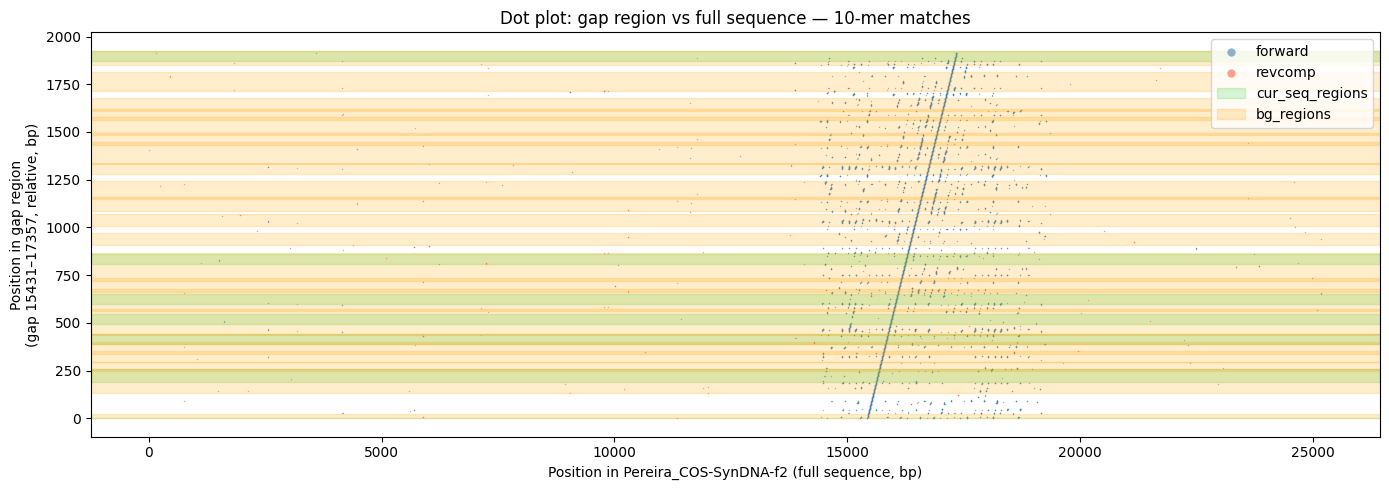

In [8]:
# %% Dot plot: Pereira_COS-SynDNA-f2 gap region vs full sequence (10-mer matches)
_dotplot_seq_id = "Pereira_COS-SynDNA-f2"
_seq = next(s for s in sequences if s.id == _dotplot_seq_id)
_full_seq = str(_seq.seq)
_gap_start, _gap_end = gaps[_dotplot_seq_id][0]
_gap_seq = _full_seq[_gap_start:_gap_end]

_k = 10

# Index all k-mers in the gap sequence
_gap_kmer_positions = {}
for _j in range(len(_gap_seq) - _k + 1):
    _km = _gap_seq[_j:_j + _k]
    _gap_kmer_positions.setdefault(_km, []).append(_j)

_comp_table = str.maketrans('ACGT', 'TGCA')
def _revcomp(s):
    return s.translate(_comp_table)[::-1]

_fw_x, _fw_y = [], []
_rc_x, _rc_y = [], []

for _i in range(len(_full_seq) - _k + 1):
    _km = _full_seq[_i:_i + _k]
    if _km in _gap_kmer_positions:
        for _j in _gap_kmer_positions[_km]:
            _fw_x.append(_i)
            _fw_y.append(_j)
    _km_rc = _revcomp(_km)
    if _km_rc in _gap_kmer_positions:
        for _j in _gap_kmer_positions[_km_rc]:
            _rc_x.append(_i)
            _rc_y.append(_j)

fig, ax = plt.subplots(figsize=(14, 5))
ax.scatter(_fw_x, _fw_y, s=1, c='steelblue', label='forward', alpha=0.6, linewidths=0)
ax.scatter(_rc_x, _rc_y, s=1, c='tomato', label='revcomp', alpha=0.6, linewidths=0)

# Overlay regions from cur_seq_regions and bg_regions that intersect the gap (y-axis = gap-relative coords)
_cur_in_gap = [(max(r[0], _gap_start) - _gap_start, min(r[1], _gap_end) - _gap_start)
               for r in local_neigh_regions[_dotplot_seq_id]
               #for r in regions
               if r[0] < _gap_end and r[1] > _gap_start]
_bg_in_gap  = [(max(r[0], _gap_start) - _gap_start, min(r[1], _gap_end) - _gap_start)
               for r in bg_regions[_dotplot_seq_id]
               if r[0] < _gap_end and r[1] > _gap_start]

_cur_label_done = False
_bg_label_done  = False
for _ys, _ye in _cur_in_gap:
    ax.axhspan(_ys, _ye, color='limegreen', alpha=0.20,
               label='cur_seq_regions' if not _cur_label_done else None)
    _cur_label_done = True
for _ys, _ye in _bg_in_gap:
    ax.axhspan(_ys, _ye, color='orange', alpha=0.20,
               label='bg_regions' if not _bg_label_done else None)
    _bg_label_done = True

ax.set_xlabel(f"Position in {_dotplot_seq_id} (full sequence, bp)")
ax.set_ylabel(f"Position in gap region\n(gap {_gap_start}–{_gap_end}, relative, bp)")
ax.set_title(f"Dot plot: gap region vs full sequence — {_k}-mer matches")
ax.legend(markerscale=6)
plt.tight_layout()
plt.show()

In [9]:
segment_overlaps = {}
for seq in sequences:
    print(seq.id)
    cur_overlaps = []
    for region in cur_seq_regions[seq.id]:
        if region[1] - region[0] < CONFIG['max_overlap'] and region[1] - region[0] >= CONFIG['min_overlap']:
            cur_overlaps.append(region)
            continue
        for start in range(region[0], region[1] - CONFIG['max_overlap'] + 1, CONFIG['min_step']):
            cur_overlaps.append((start, start + CONFIG['max_overlap']))
        for end in range(region[1], region[0] + CONFIG['max_overlap'] - 1, -CONFIG['min_step']):
            cur_overlaps.append((end - CONFIG['max_overlap'], end))
    segment_overlaps[seq.id] = sorted(cur_overlaps, key=lambda x: x[0])

Maizel_COS-AT1G27430-GYF2
Maizel_COS-SETH5
Pereira_COS-SynDNA-f1
Pereira_COS-SynDNA-f2
PV252688r_p6utr
MZ289137_rep
OR500095r_naive
PX021458r_p6utr


In [10]:
def get_edge_penalty(left_ov, right_ov, 
                     opt_primer_len, max_primer_len_diff, 
                     opt_overlap_len, max_overlap_len_diff, 
                     max_tm_diff=5.0):
    penalty = 0.0
    if left_ov['type'] == 'fr' and right_ov['type'] == 'fr':
        tm_diff = abs(left_ov['tm_left'] - right_ov['tm_right'])
        penalty += tm_diff / max_tm_diff * 0.1
    
    if left_ov['type'] == 'fr':
        primer_len_diff = abs(left_ov['pr_left_len'] - opt_primer_len)
        penalty += primer_len_diff / max_primer_len_diff * 0.1
    if right_ov['type'] == 'fr':
        primer_len_diff = abs(right_ov['pr_right_len'] - opt_primer_len)
        penalty += primer_len_diff / max_primer_len_diff * 0.1
    
    left_overlap_len = left_ov['pos'][1] - left_ov['pos'][0]
    right_overlap_len = right_ov['pos'][1] - right_ov['pos'][0]
    penalty += abs(left_overlap_len - opt_overlap_len) / max_overlap_len_diff * 0.1
    penalty += abs(right_overlap_len - opt_overlap_len) / max_overlap_len_diff * 0.1

    return round(penalty * 100)

def get_edge_clamp(left_ov, right_ov):
    return left_ov['left_clamp'] + right_ov['right_clamp']


# %%

segment_offset_left = 78
segment_offset_right = 108
#offsets: for primers 40 in total, for segments 110 (from each side)

def get_all_overlaps(primer_flanked_overlaps, segment_overlaps, seq_len):
    all_overlaps = (
        [
            {'pos': ov, 'type': 'seg'} 
            for ov in segment_overlaps
        ] +
        [
            {
                'pos': ov['pos'], 
                'type': 'fr', 
                'pr_ind': i,
                'left_clamp': 3 if ov['forward']['seq'][0] == 'G' else 2,
                'right_clamp': 3 if ov['reverse']['seq'][0] == 'G' else 2,
                'pr_left_len': len(ov['forward']['seq']),
                'pr_right_len': len(ov['reverse']['seq']),
                'tm_left': ov['forward']['tm'],
                'tm_right': ov['reverse']['tm']
            } 
            for i, ov in enumerate(primer_flanked_overlaps)
        ] +
        [
            {'pos': (-100, 0), 'type': 'seg'}, 
            {'pos': (seq_len, seq_len + 100), 'type': 'seg'}
        ]
    )
    return sorted(all_overlaps, key=lambda x: x['pos'][0])

def get_overlap_states(all_overlaps, min_length, max_length, n_frags_min, n_frags_max,
                       segment_offset_left, segment_offset_right, max_overlap, min_overlap, 
                       max_primer_length, min_primer_length):

    opt_primer_len = 20
    max_primer_len_diff = 3

    overlap_states = [{} for _ in range(len(all_overlaps))]

    overlap_states[0][(0, 0)] = (0, -1, None) # state: (n_frags, clamp_code): (weight, predecessor_ind, predecessor_state)

    for i, ov in enumerate(all_overlaps):

        if i % 1000 == 0:
            print(f"Processing overlap {i}/{len(all_overlaps)}")
        if len(overlap_states[i]) == 0:
            continue
        j = i + 1
        too_far = False
        while j < len(all_overlaps) and not too_far:
            next_ov = all_overlaps[j]
            if next_ov['pos'][0] - max(ov['pos'][0], 0) > max_length:
                too_far = True
                continue
            length = next_ov['pos'][1] - max(ov['pos'][0], 0)
            if min_length <= length <= max_length:
                edge_weight = 100 + get_edge_penalty(ov, next_ov, 
                                                    opt_primer_len, max_primer_len_diff, 
                                                    max_overlap, max_overlap - min_overlap)
                for state, (cur_weight, _, _) in overlap_states[i].items():
                    new_segment_started = False
                    new_n_frag = state[0] + 1
                    if new_n_frag >= n_frags_max:
                        new_n_frag = 0
                        new_segment_started = True

                    new_clamp = state[1]
                    new_weight = cur_weight + edge_weight

                    if next_ov['type'] == 'seg':
                        if new_n_frag >= n_frags_min:
                            new_n_frag = 0
                            new_segment_started = True
                        else:
                            continue
                    # clamp-based restrictions
                    elif new_n_frag == 1:
                        # we have just started
                        new_clamp = next_ov['right_clamp']
                    else:
                        if not new_segment_started:
                            # we first attempt to continue segment, and if not possible, stop it prematurely
                            failed = False
                            # in the middle of the segment, both clamps matter
                            edge_clamp = ov['left_clamp'] + next_ov['right_clamp']

                            # at this point we know that we are at a middle fragment, edge_clamp > 3
                            # if not, something went very wrong
                            if edge_clamp <= 3:
                                raise ValueError(f"Unexpected clamp code {edge_clamp} for edge between {ov} and {next_ov}")

                            if state[1] > 3 and state[1] != edge_clamp:
                                failed = True
                            else:
                                if state[1] == 2 and edge_clamp == 6: # C vs GG
                                    failed = True    
                                elif state[1] == 3 and edge_clamp == 4: # G vs CC
                                    failed = True
                            if failed and new_n_frag >= n_frags_min:
                                new_n_frag = 0
                                new_segment_started = True
                                new_weight += (n_frags_max - new_n_frag) * 100 # penalty for stopping segment prematurely
                
                            if new_clamp <= 3 and edge_clamp > 3:
                                new_clamp = edge_clamp

                            #technically, this should never happen, since it requires a very small segment
                            if new_clamp <= 3 and edge_clamp <= 3 and new_clamp != edge_clamp:
                                new_clamp += edge_clamp

                    if new_segment_started:
                        # end of the segmented = True, only left clamp of the current vertex matters (left of the new edge)
                        if ov['type'] == 'fr':
                            if ov['left_clamp'] == 2 and new_clamp == 6: # C vs GG
                                continue
                            elif ov['left_clamp'] == 3 and new_clamp == 4: # G vs CC
                                continue
                        new_clamp = 0
                    
                    # the first and last fragments in a segment require an extra offsest, therefore check once more for the length limit
                    if new_segment_started:
                        if length + segment_offset_left > max_length:
                            continue
                    if state[1] == 0:
                        if length + segment_offset_right > max_length:
                            continue
                    
                    new_state = (new_n_frag, new_clamp)
                    existing = overlap_states[j].get(new_state)
                    if existing is None or new_weight < existing[0]:
                        overlap_states[j][new_state] = (new_weight, i, state)
            j += 1
    return overlap_states

In [11]:
full_overlap_states = {}
full_all_overlaps  = {}
for seq in sequences:
    print(seq.id)
    full_all_overlaps[seq.id] = get_all_overlaps(primer_flanked_overlaps[seq.id], segment_overlaps[seq.id], len(str(seq.seq)))
    full_overlap_states[seq.id] = get_overlap_states(full_all_overlaps[seq.id], min_length, max_length, n_frags_min, n_frags_max,
                                                      segment_offset_left, segment_offset_right, max_overlap, min_overlap, 
                                                      CONFIG['max_primer_length'], CONFIG['min_primer_length'])


Maizel_COS-AT1G27430-GYF2
Processing overlap 0/873
Maizel_COS-SETH5
Processing overlap 0/936
Pereira_COS-SynDNA-f1
Processing overlap 0/2152
Processing overlap 1000/2152
Processing overlap 2000/2152
Pereira_COS-SynDNA-f2
Processing overlap 0/2585
Processing overlap 1000/2585
Processing overlap 2000/2585
PV252688r_p6utr
Processing overlap 0/1977
Processing overlap 1000/1977
MZ289137_rep
Processing overlap 0/2438
Processing overlap 1000/2438
Processing overlap 2000/2438
OR500095r_naive
Processing overlap 0/1949
Processing overlap 1000/1949
PX021458r_p6utr
Processing overlap 0/1501
Processing overlap 1000/1501


In [12]:
for seq_id in full_overlap_states:
    print(seq_id)
    print(full_overlap_states[seq_id][-1])

Maizel_COS-AT1G27430-GYF2
{(0, 0): (987, 836, (1, 3))}
Maizel_COS-SETH5
{(0, 0): (1379, 906, (1, 3))}
Pereira_COS-SynDNA-f1
{(0, 0): (3399, 2104, (1, 2))}
Pereira_COS-SynDNA-f2
{}
PV252688r_p6utr
{(0, 0): (1178, 1905, (1, 2))}
MZ289137_rep
{(0, 0): (1082, 2344, (3, 5))}
OR500095r_naive
{(0, 0): (1162, 1716, (1, 2))}
PX021458r_p6utr
{(0, 0): (1208, 1337, (1, 2))}


In [16]:
def reconstruct_shortest_path(overlap_states, end_index=None):
    path = []
    current_index = len(overlap_states) - 1 if end_index is None else end_index
    current_state = min(overlap_states[current_index].items(), key=lambda x: x[1][0])[0]

    while current_index != -1:
        path.append((current_index, current_state))
        _, predecessor_index, predecessor_state = overlap_states[current_index][current_state]
        current_index = predecessor_index
        current_state = predecessor_state

    return path[::-1]

seq_id = "PX021458r_p6utr"
reconstruct_shortest_path(full_overlap_states[seq_id])


[(0, (0, 0)),
 (83, (1, 3)),
 (251, (2, 5)),
 (372, (0, 0)),
 (460, (1, 2)),
 (665, (2, 4)),
 (730, (0, 0)),
 (793, (1, 3)),
 (928, (2, 5)),
 (1051, (0, 0)),
 (1337, (1, 2)),
 (1500, (0, 0))]

In [40]:
fragments = []
path = reconstruct_shortest_path(full_overlap_states[seq_id])
for i in range(1, len(path)):
    prev_index, prev_state = path[i-1]
    curr_index, curr_state = path[i]
    prev_ov = full_all_overlaps[seq_id][prev_index]
    curr_ov = full_all_overlaps[seq_id][curr_index]
    fragment_start = max(prev_ov['pos'][0], 0)
    fragment_end = min(curr_ov['pos'][1], len(sequences_by_id[seq_id].seq))
    fragments.append((fragment_start, fragment_end))



In [41]:
fragments

[(0, 778),
 (724, 1567),
 (1484, 2418),
 (2324, 3284),
 (3232, 4140),
 (4087, 4968),
 (4908, 5706),
 (5615, 6537),
 (6486, 7439),
 (7369, 8151)]

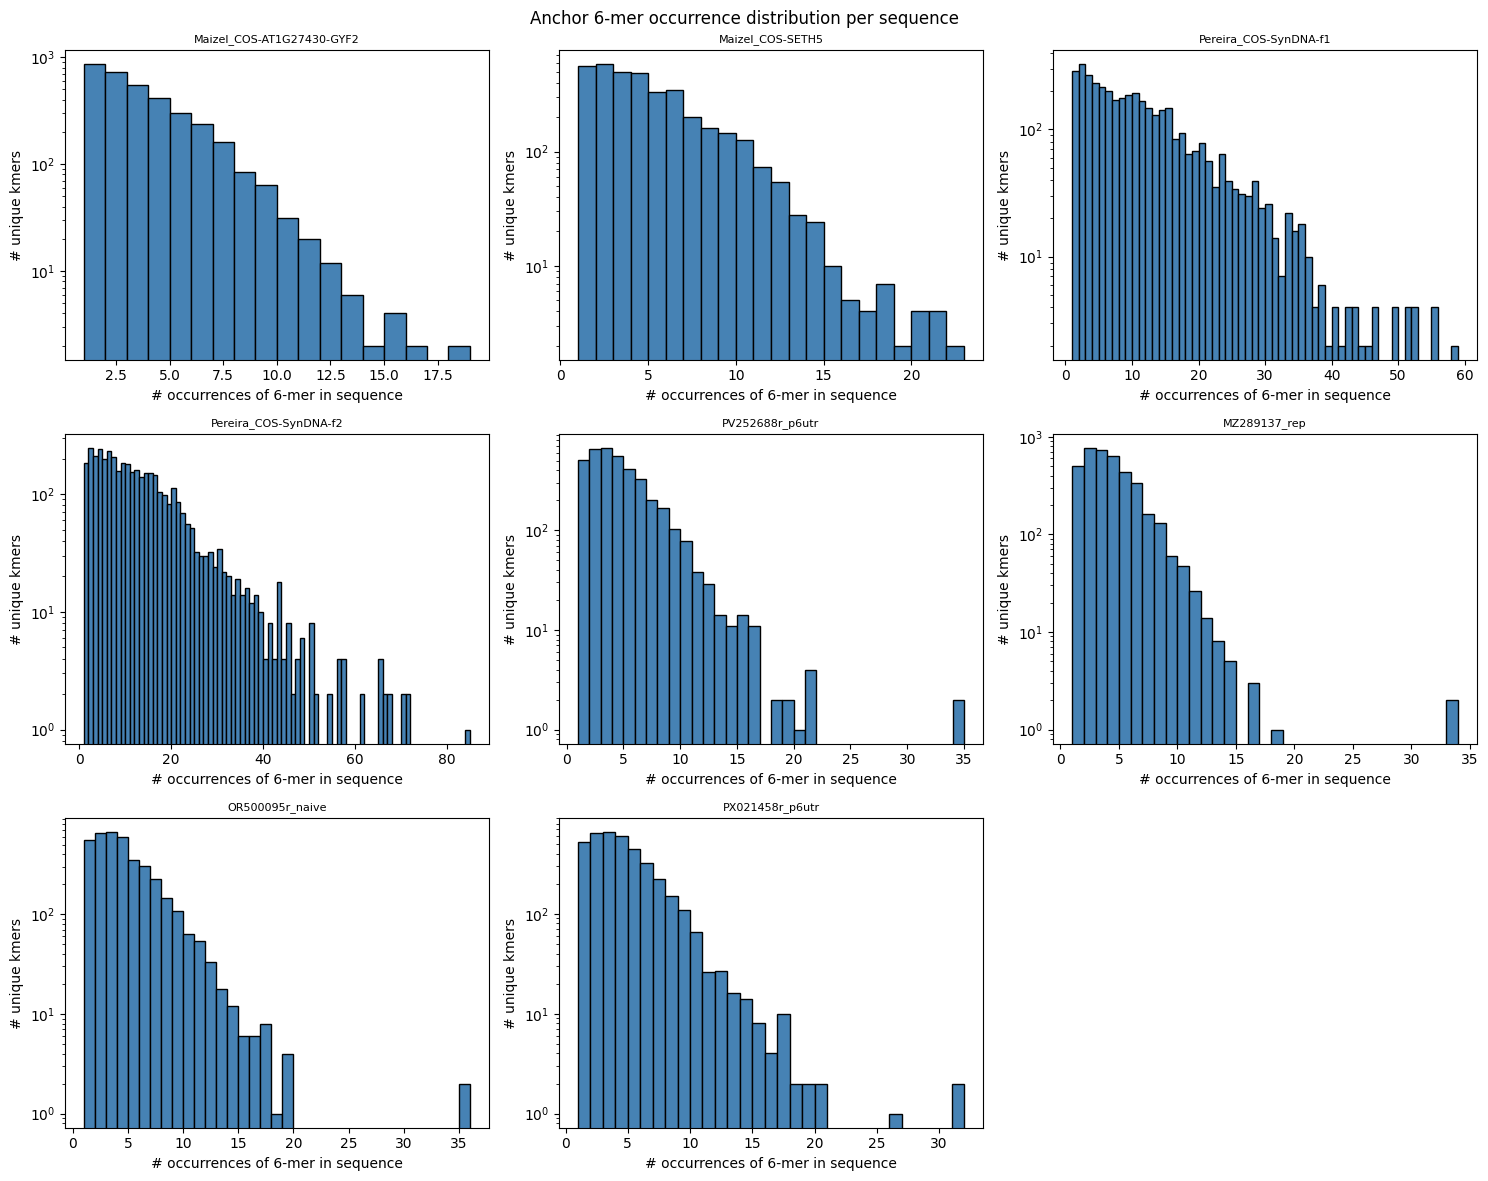

In [7]:
from collections import Counter

seq_ids = list(sequences_by_id.keys())
kmer_counts_per_seq = {sid: Counter() for sid in seq_ids}
for kmer, hits in anchor_kmers.items():
    for seq_id, pos, strand in hits:
        kmer_counts_per_seq[seq_id][kmer] += 1

anchor_len = CONFIG['primer_3prime_anchor']
n = len(seq_ids)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for i, seq_id in enumerate(seq_ids):
    counts = list(kmer_counts_per_seq[seq_id].values())
    max_count = max(counts) if counts else 1
    axes_flat[i].hist(counts, bins=range(1, max_count + 2), color='steelblue', edgecolor='black')
    axes_flat[i].set_title(seq_id, fontsize=8)
    axes_flat[i].set_xlabel(f"# occurrences of {anchor_len}-mer in sequence")
    axes_flat[i].set_ylabel("# unique kmers")
    axes_flat[i].set_yscale('log')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Anchor {anchor_len}-mer occurrence distribution per sequence")
plt.tight_layout()
plt.show()


In [19]:
hom_anchors = build_anchor_kmers(sequences, CONFIG['homology_anchor'], reverse_position=False)

seq_id = sequences[3].id
seq_str = str(sequences[3].seq)

mask = [0] * len(seq_str)

dist_threshold = CONFIG['homology_check'] * 0.2
for pos in range(CONFIG['homology_anchor'], len(seq_str)):
    kmer_start = pos - CONFIG['homology_anchor']
    kmer = seq_str[kmer_start:pos]
    other_ocs = filter(lambda oc: oc[0] == seq_id and abs(oc[1] - pos) < CONFIG['neighbourhood_size'], hom_anchors.get(kmer, []))
    for oc in other_ocs:
        if oc[1] == pos - 1:
            continue

        left_side = seq_str[max(0, pos - CONFIG['homology_check']):pos]
        right_side = seq_str[kmer_start:min(len(seq_str), kmer_start + CONFIG['homology_check'])]
        oc_left_side = seq_str[max(0, oc[1] - CONFIG['homology_check'] + 1):(oc[1] + 1)]
        oc_right_side = seq_str[(oc[1] + 1 - CONFIG['homology_anchor']):min(len(seq_str), oc[1] + CONFIG['homology_check']- CONFIG['homology_anchor'] + 1)]
        if oc[2] == "reverse":
            oc_left_side = reverse_complement(oc_left_side)
            oc_right_side = reverse_complement(oc_right_side)
        
        left_dist = edlib.align(left_side[::-1], oc_left_side[::-1], mode="SHW", task="distance")['editDistance']
        right_dist = edlib.align(right_side, oc_right_side, mode="SHW", task="distance")['editDistance']

        left_dist += abs(len(left_side) - len(oc_left_side))
        right_dist += abs(len(right_side) - len(oc_right_side))

        if left_dist > dist_threshold and right_dist > dist_threshold:
            continue
        
        mask[pos] = 1
        mask[kmer_start] = 1
        print(f"Anchor {kmer} at pos {pos} has nearby occurrence at pos {oc[1]} on strand {oc[2]}")
        print(f"  Left side: {left_side} vs {oc_left_side} (dist {left_dist})")
        print(f"  Right side: {right_side} vs {oc_right_side} (dist {right_dist})\n")



Anchor TCTCTC at pos 767 has nearby occurrence at pos 768 on strand forward
  Left side: TTAAAAGGAATCCCTCACATCGCCCCTCGGCTACAACGCTTCTCTC vs AAAAGGAATCCCTCACATCGCCCCTCGGCTACAACGCTTCTCTCTC (dist 4)
  Right side: TCTCTCTCGAGGCATCGTAGCTCGGCTTGTCCAGAAGTGCTTACCC vs TCTCTCGAGGCATCGTAGCTCGGCTTGTCCAGAAGTGCTTACCCCC (dist 2)

Anchor TCTCTC at pos 769 has nearby occurrence at pos 766 on strand forward
  Left side: AAAAGGAATCCCTCACATCGCCCCTCGGCTACAACGCTTCTCTCTC vs TTAAAAGGAATCCCTCACATCGCCCCTCGGCTACAACGCTTCTCTC (dist 2)
  Right side: TCTCTCGAGGCATCGTAGCTCGGCTTGTCCAGAAGTGCTTACCCCC vs TCTCTCTCGAGGCATCGTAGCTCGGCTTGTCCAGAAGTGCTTACCC (dist 4)

Anchor AAAAAA at pos 884 has nearby occurrence at pos 884 on strand forward
  Left side: TATTAGAAGAAATAAAAAATTCGAAGCATAACACACCAAGAAAAAA vs ATTAGAAGAAATAAAAAATTCGAAGCATAACACACCAAGAAAAAAA (dist 2)
  Right side: AAAAAAAACAAACCCCAGCAGAATCAGGATAGCTTTGGGAAATGAA vs AAAAAAACAAACCCCAGCAGAATCAGGATAGCTTTGGGAAATGAAG (dist 1)

Anchor AAAAAA at pos 884 has nearby occurrence at po

In [42]:
def _parse_cigar(cigar):
    ops = []
    i = 0
    while i < len(cigar):
        j = i
        while j < len(cigar) and cigar[j].isdigit():
            j += 1
        count = int(cigar[i:j]) if j > i else 1
        ops.extend([cigar[j]] * count)
        i = j + 1
    return ops

def _build_aligned(s1, s2, ops):
    a1, a2, am = [], [], []
    i1 = i2 = 0
    for op in ops:
        if op in ('=', 'X'):
            a1.append(s1[i1]); a2.append(s2[i2])
            am.append('|' if op == '=' else '.')
            i1 += 1; i2 += 1
        elif op == 'I':          # gap in target
            a1.append(s1[i1]); a2.append('-'); am.append(' '); i1 += 1
        elif op == 'D':          # gap in query
            a1.append('-'); a2.append(s2[i2]); am.append(' '); i2 += 1
    return ''.join(a1), ''.join(a2), ''.join(am)

def visualize_alignment(s1, s2, label1="s1", label2="s2", anchored="global"):
    """
    Print a pairwise alignment between s1 and s2.
    anchored: 'global' (NW), 'left' (SHW from left), 'right' (SHW from right)
    """
    if anchored == "right":
        result = edlib.align(s1[::-1], s2[::-1], mode="SHW", task="path")
        ops = _parse_cigar(result['cigar'])[::-1]
        a1, a2, am = _build_aligned(s1[::-1], s2[::-1], _parse_cigar(result['cigar']))
        a1, a2, am = a1[::-1], a2[::-1], am[::-1]
    elif anchored == "left":
        result = edlib.align(s1, s2, mode="SHW", task="path")
        a1, a2, am = _build_aligned(s1, s2, _parse_cigar(result['cigar']))
    else:
        result = edlib.align(s1, s2, mode="NW", task="path")
        a1, a2, am = _build_aligned(s1, s2, _parse_cigar(result['cigar']))

    dist = result['editDistance']
    w = max(len(label1), len(label2))
    matches = am.count('|')
    print(f"Edit distance: {dist}  |  matches: {matches}/{len(am)}")
    print(f"{label1:>{w}}: {a1}")
    print(f"{'':>{w}}  {am}")
    print(f"{label2:>{w}}: {a2}")


In [46]:
visualize_alignment("GTGATGGAATACTGTGATGGAGGGGATCTAATGCAAAAGATTAAAC", "GTGATGGAGGGGATCTAATGCAAAAGATTAAACAGCAGAAAGGAAA", anchored="left")

Edit distance: 13  |  matches: 33/46
s1: GTGATGGAATACTGTGATGGAGGGGATCTAATGCAAAAGATTAAAC
    ||||||||     | |  |||     ||||||||||||||||||||
s2: GTGATGGA-----G-G--GGA-----TCTAATGCAAAAGATTAAAC


In [20]:
regions = []
start = None
for i, val in enumerate(mask):
    if val == 0:
        if start is None:
            start = i
    else:
        if start is not None and i - start - 1 >= 50:
            regions.append((start, i - 1))
        start = None

if start is not None and len(mask) - start >= 50:
    regions.append((start, len(mask) - 1))   

In [21]:
regions

[(0, 760),
 (770, 877),
 (887, 1114),
 (1132, 1651),
 (1666, 1950),
 (2014, 2222),
 (2233, 2788),
 (2800, 2954),
 (2968, 3041),
 (3061, 3141),
 (3221, 3410),
 (3422, 3486),
 (3503, 3696),
 (3748, 4558),
 (4567, 5169),
 (5185, 5266),
 (5281, 6613),
 (6629, 7109),
 (7122, 7309),
 (7326, 7431),
 (7447, 7638),
 (7653, 7944),
 (7956, 8368),
 (8380, 8461),
 (8517, 8701),
 (8761, 9465),
 (9482, 9616),
 (9632, 9769),
 (9900, 10277),
 (10294, 11523),
 (11536, 11588),
 (11602, 11712),
 (11727, 12115),
 (12124, 12338),
 (12358, 12472),
 (12486, 12823),
 (13016, 14369),
 (18984, 19055),
 (19317, 19483),
 (19495, 19649),
 (19666, 20036),
 (20054, 20197),
 (20209, 20296),
 (20311, 20516),
 (20527, 20643),
 (20654, 21154),
 (21169, 21405),
 (21767, 21881),
 (21895, 22352),
 (22421, 22967),
 (23025, 23368),
 (23383, 23611),
 (23628, 23864),
 (23873, 24224),
 (24236, 24679),
 (24696, 24753),
 (24768, 25184),
 (25205, 25304)]

In [47]:
RELAXED_CONFIG = {
    'kmer_size': 15,
    'neighbourhood_size': 4500,
    'max_frag_length': 1000 - 40,
    'min_frag_length': max(100 - 40, min_overlap*2 + 40),    
    'min_primer_length': 17,
    'max_primer_length': 30,
    'primer_3prime_anchor': 6,
    'clamp_length': 1,
    'min_gc': 0.3,
    'max_gc': 0.7,
    'min_tm': 57.0,
    'max_tm': 65.0,
    'max_hairpin_tm': 24.0,
    'max_homodimer_tm': 45.0,
    'max_3_self_tm': 35.0,
    'max_misprime_tm': 50.0,
    'min_overlap': 50,
    'max_overlap': 120,
    'poly_x_pattern': re.compile(r'(A{5,}|T{5,}|G{5,}|C{5,})'),
    'clamp_pattern': re.compile(r'[GC]'),
    'five_prime_clamp_pattern': re.compile(r'^[ATGC]')
}

primer_flanked_overlaps_relaxed = {}

for seq in sequences:
    print(seq.id)
    if len(gaps[seq.id]) > 0:
        primer_regions = list(filter(lambda x: any(gap_start <= x[0] < gap_end or gap_start < x[1] <= gap_end for gap_start, gap_end in gaps[seq.id]), local_neigh_regions[seq.id]))
        overlap_regions = list(filter(lambda x: any(gap_start <= x[0] < gap_end or gap_start < x[1] <= gap_end for gap_start, gap_end in gaps[seq.id]), local_neigh_regions[seq.id]))
        primer_flanked_overlaps_relaxed[seq.id] = find_primer_flanked_overlaps(seq, primer_regions, overlap_regions, anchor_kmers, sequences_by_id, RELAXED_CONFIG)
        primer_flanked_overlaps_relaxed[seq.id] = [ov for ov in primer_flanked_overlaps_relaxed[seq.id] 
                                                   if any(gap_start <= ov['pos'][0] < gap_end and gap_start < ov['pos'][1] <= gap_end 
                                                          for gap_start, gap_end in gaps[seq.id])]

Maizel_COS-AT1G27430-GYF2
Maizel_COS-SETH5
Pereira_COS-SynDNA-f1
Pereira_COS-SynDNA-f2
PV252688r_p6utr
MZ289137_rep
OR500095r_naive
PX021458r_p6utr


In [110]:
primer_flanked_overlaps_relaxed

{'Pereira_COS-SynDNA-f2': [{'forward': {'seq': 'ACCAACAGTGTCCTCTAATTCTC',
    'gc_content': 0.43478260869565216,
    'tm': 57.8460503496907,
    'pos': (15629, 15652),
    'side': 'forward'},
   'reverse': {'seq': 'AAACACTAGATTTCTCGCTATGTG',
    'gc_content': 0.375,
    'tm': 57.10604234329588,
    'pos': (15655, 15679),
    'side': 'reverse'},
   'pos': (15629, 15679)},
  {'forward': {'seq': 'ACCAACAGTGTCCTCTAATTCTC',
    'gc_content': 0.43478260869565216,
    'tm': 57.8460503496907,
    'pos': (15629, 15652),
    'side': 'forward'},
   'reverse': {'seq': 'AAAACACTAGATTTCTCGCTATGTG',
    'gc_content': 0.36,
    'tm': 57.70404789801245,
    'pos': (15655, 15680),
    'side': 'reverse'},
   'pos': (15629, 15680)},
  {'forward': {'seq': 'CCAACAGTGTCCTCTAATTCTCAC',
    'gc_content': 0.4583333333333333,
    'tm': 59.06780020833202,
    'pos': (15630, 15654),
    'side': 'forward'},
   'reverse': {'seq': 'AAAACACTAGATTTCTCGCTATGTG',
    'gc_content': 0.36,
    'tm': 57.70404789801245,
    '

In [48]:
gap_threshold = 1.5 * max_length
gaps = {}

for seq in sequences:
    seq_len = len(seq.seq)
    gaps[seq.id] = []
    
    if primer_flanked_overlaps[seq.id]:
        overlaps = sorted([
            ov['pos'] 
            for ov in primer_flanked_overlaps[seq.id] + primer_flanked_overlaps_relaxed.get(seq.id, [])
        ])
        
        if overlaps[0][0] > gap_threshold:
            gaps[seq.id].append((0, overlaps[0][0]))
        
        for i in range(len(overlaps) - 1):
            gap_start = overlaps[i][1]
            gap_end = overlaps[i + 1][0]
            gap_size = gap_end - gap_start
            if gap_size > gap_threshold:
                gaps[seq.id].append((gap_start, gap_end))
        
        if overlaps[-1][1] < seq_len - gap_threshold:
            gaps[seq.id].append((overlaps[-1][1], seq_len))
    else:
        gaps[seq.id].append((0, seq_len))

for seq in sequences:
    print(f"\n{seq.id}: {len(gaps[seq.id])} gaps found")
    for i, (gap_start, gap_end) in enumerate(gaps[seq.id]):
        print(f"  Gap {i+1}: {gap_start}-{gap_end} (length: {gap_end - gap_start})")


Maizel_COS-AT1G27430-GYF2: 0 gaps found

Maizel_COS-SETH5: 0 gaps found

Pereira_COS-SynDNA-f1: 0 gaps found

Pereira_COS-SynDNA-f2: 1 gaps found
  Gap 1: 15680-17357 (length: 1677)

PV252688r_p6utr: 0 gaps found

MZ289137_rep: 0 gaps found

OR500095r_naive: 0 gaps found

PX021458r_p6utr: 0 gaps found


In [23]:
list(filter(lambda r: r[1] > 14500, regions))

[(18984, 19055),
 (19317, 19483),
 (19495, 19649),
 (19666, 20036),
 (20054, 20197),
 (20209, 20296),
 (20311, 20516),
 (20527, 20643),
 (20654, 21154),
 (21169, 21405),
 (21767, 21881),
 (21895, 22352),
 (22421, 22967),
 (23025, 23368),
 (23383, 23611),
 (23628, 23864),
 (23873, 24224),
 (24236, 24679),
 (24696, 24753),
 (24768, 25184),
 (25205, 25304)]

In [17]:
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation
import os


def _is_virtual_sentinel(ov, seq_len):
    """True for the two dummy bookend overlaps added in get_all_overlaps."""
    return ov['pos'][1] <= 0 or ov['pos'][0] >= seq_len


def generate_annotated_genbank(seq_id, sequences_by_id, full_overlap_states, full_all_overlaps,
                                cur_seq_regions, primer_flanked_overlaps_dict, end_index=None):
    """Generate an annotated GenBank record for a sequence with a valid assembly path.

    Features annotated:
      - misc_feature : non-homologous regions (cur_seq_regions)
      - repeat_region: every real overlap node in the path (excl. virtual sentinels)
      - gene         : each assembly segment (between n_frags==0 nodes)
      - misc_feature : each PCR fragment within a segment
      - primer_bind  : fwd/rev primers for 'fr'-type overlaps strictly inside a segment
    """
    states = full_overlap_states[seq_id]
    all_overlaps = full_all_overlaps[seq_id]

    check_index = end_index if end_index is not None else len(states) - 1
    if not states[check_index]:
        return None

    path = reconstruct_shortest_path(states, end_index)
    seq_record = sequences_by_id[seq_id]
    seq_len = len(seq_record.seq)

    new_record = SeqRecord(
        seq_record.seq,
        id=seq_id[:16],
        name=seq_id[:16],
        description=seq_id,
        annotations={"molecule_type": "DNA"},
    )

    features = []

    # --- Non-homologous regions ---
    for start, end in cur_seq_regions.get(seq_id, []):
        features.append(SeqFeature(
            FeatureLocation(start, end),
            type="misc_feature",
            qualifiers={"label": ["non_homologous"],
                        "note": ["non-homologous region"]},
        ))

    # --- All real overlap nodes ---
    for ov_idx, state in path:
        ov = all_overlaps[ov_idx]
        if _is_virtual_sentinel(ov, seq_len):
            continue
        ov_type = ov['type']
        label_prefix = "junc" if state[0] == 0 else "ov"
        features.append(SeqFeature(
            FeatureLocation(ov['pos'][0], ov['pos'][1]),
            type="repeat_region",
            qualifiers={
                "label":    [f"{label_prefix}_{ov['pos'][0]}_{ov['pos'][1]}"],
                "note":     [f"overlap type={ov_type}, n_frags={state[0]}, clamp={state[1]}"],
                "rpt_type": ["overlap"],
            },
        ))

    # --- Segments: slices of path between consecutive n_frags==0 nodes ---
    boundary_path_indices = [
        i for i, (ov_idx, state) in enumerate(path)
        if state[0] == 0
    ]
    # For partial paths that end mid-segment, include the last node as a boundary
    if path and path[-1][1][0] != 0:
        boundary_path_indices.append(len(path) - 1)

    segment_num = 0
    for si in range(len(boundary_path_indices) - 1):
        pa = boundary_path_indices[si]
        pb = boundary_path_indices[si + 1]
        seg_slice = path[pa : pb + 1]
        # seg_slice[0]  = left junction (n_frags==0)
        # seg_slice[-1] = right junction (n_frags==0)
        # seg_slice[1:-1] = interior overlaps of this segment

        left_ov  = all_overlaps[seg_slice[0][0]]
        right_ov = all_overlaps[seg_slice[-1][0]]

        # Skip vacuous slices produced entirely from virtual sentinels
        if _is_virtual_sentinel(left_ov, seq_len) and _is_virtual_sentinel(right_ov, seq_len):
            continue

        seg_start = max(left_ov['pos'][0], 0)
        seg_end   = min(right_ov['pos'][1], seq_len)

        segment_num += 1
        n_frags = len(seg_slice) - 1

        # Segment feature
        features.append(SeqFeature(
            FeatureLocation(seg_start, seg_end),
            type="gene",
            qualifiers={
                "label": [f"Segment_{segment_num}"],
                "note":  [f"Assembly segment {segment_num}, {n_frags} fragment(s)"],
            },
        ))

        # Fragment features (one per edge in the slice)
        for j in range(1, len(seg_slice)):
            l_ov = all_overlaps[seg_slice[j - 1][0]]
            r_ov = all_overlaps[seg_slice[j][0]]
            frag_start = max(l_ov['pos'][0], 0)
            frag_end   = min(r_ov['pos'][1], seq_len)
            features.append(SeqFeature(
                FeatureLocation(frag_start, frag_end),
                type="misc_feature",
                qualifiers={
                    "label": [f"S{segment_num}_F{j}"],
                    "note":  [f"Segment {segment_num}, fragment {j}"],
                },
            ))

        # Primer features for interior 'fr'-type overlaps
        for j in range(1, len(seg_slice) - 1):
            ov_idx, _ = seg_slice[j]
            ov = all_overlaps[ov_idx]
            if ov['type'] != 'fr':
                continue

            pr_data = primer_flanked_overlaps_dict[seq_id][ov['pr_ind']]
            fwd = pr_data['forward']
            rev = pr_data['reverse']

            features.append(SeqFeature(
                FeatureLocation(fwd['pos'][0], fwd['pos'][1], strand=1),
                type="primer_bind",
                qualifiers={
                    "label":    [f"S{segment_num}_Ov{j}_F"],
                    "note":     [f"Fwd primer Tm={fwd['tm']:.1f} GC={fwd['gc_content']:.2f}"],
                    "sequence": [fwd['seq']],
                },
            ))
            features.append(SeqFeature(
                FeatureLocation(rev['pos'][0], rev['pos'][1], strand=-1),
                type="primer_bind",
                qualifiers={
                    "label":    [f"S{segment_num}_Ov{j}_R"],
                    "note":     [f"Rev primer Tm={rev['tm']:.1f} GC={rev['gc_content']:.2f}"],
                    "sequence": [rev['seq']],
                },
            ))

    new_record.features = sorted(features, key=lambda f: f.location.start)
    return new_record


def extract_fragment_records(seq_id, sequences_by_id, path, all_overlaps):
    """Return a list of SeqRecords, one per fragment edge in the path."""
    seq_record = sequences_by_id[seq_id]
    seq_len = len(seq_record.seq)
    frag_records = []
    frag_num = 0
    for i in range(1, len(path)):
        prev_ov = all_overlaps[path[i - 1][0]]
        curr_ov = all_overlaps[path[i][0]]
        frag_start = max(prev_ov['pos'][0], 0)
        frag_end   = min(curr_ov['pos'][1], seq_len)
        if frag_start >= frag_end:
            continue
        frag_num += 1
        frag_records.append(SeqRecord(
            seq_record.seq[frag_start:frag_end],
            id=f"{seq_id}_F{frag_num}",
            name=f"{seq_id}_F{frag_num}"[:16],
            description=f"fragment {frag_num} pos={frag_start}-{frag_end}",
        ))
    return frag_records


# Write GenBank and FASTA files for every sequence
os.makedirs("annotated", exist_ok=True)

for seq_id in full_overlap_states:
    states = full_overlap_states[seq_id]
    end_index = None
    partial = False

    if not states[-1]:
        # Find the last reachable overlap index
        last_idx = None
        for idx in range(len(states) - 1, -1, -1):
            if states[idx]:
                last_idx = idx
                break
        if last_idx is None or last_idx == 0:
            print(f"{seq_id}: no solution found, skipping")
            continue
        end_index = last_idx
        partial = True
        print(f"{seq_id}: partial solution found (up to overlap index {last_idx})")

    record = generate_annotated_genbank(
        seq_id,
        sequences_by_id,
        full_overlap_states,
        full_all_overlaps,
        cur_seq_regions,
        primer_flanked_overlaps,
        end_index=end_index,
    )
    if record is None:
        print(f"{seq_id}: no solution found, skipping")
        continue

    suffix = "_partial" if partial else ""

    # Write GenBank
    out_gb = f"annotated/{seq_id}{suffix}.gb"
    with open(out_gb, "w") as fh:
        SeqIO.write(record, fh, "genbank")
    print(f"Written: {out_gb}  ({len(record.features)} features)")

    # Write FASTA fragments
    path = reconstruct_shortest_path(states, end_index)
    frag_records = extract_fragment_records(seq_id, sequences_by_id, path, full_all_overlaps[seq_id])
    out_fa = f"annotated/{seq_id}{suffix}_fragments.fa"
    with open(out_fa, "w") as fh:
        SeqIO.write(frag_records, fh, "fasta")
    print(f"Written: {out_fa}  ({len(frag_records)} fragments)")


Written: annotated/Maizel_COS-AT1G27430-GYF2.gb  (82 features)
Written: annotated/Maizel_COS-AT1G27430-GYF2_fragments.fa  (8 fragments)
Written: annotated/Maizel_COS-SETH5.gb  (122 features)
Written: annotated/Maizel_COS-SETH5_fragments.fa  (12 fragments)
Written: annotated/Pereira_COS-SynDNA-f1.gb  (291 features)
Written: annotated/Pereira_COS-SynDNA-f1_fragments.fa  (28 fragments)
Pereira_COS-SynDNA-f2: partial solution found (up to overlap index 1998)
Written: annotated/Pereira_COS-SynDNA-f2_partial.gb  (293 features)
Written: annotated/Pereira_COS-SynDNA-f2_partial_fragments.fa  (22 fragments)
Written: annotated/PV252688r_p6utr.gb  (99 features)
Written: annotated/PV252688r_p6utr_fragments.fa  (11 fragments)
Written: annotated/MZ289137_rep.gb  (89 features)
Written: annotated/MZ289137_rep_fragments.fa  (10 fragments)
Written: annotated/OR500095r_naive.gb  (103 features)
Written: annotated/OR500095r_naive_fragments.fa  (11 fragments)
Written: annotated/PX021458r_p6utr.gb  (113 featu